# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [5]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [6]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


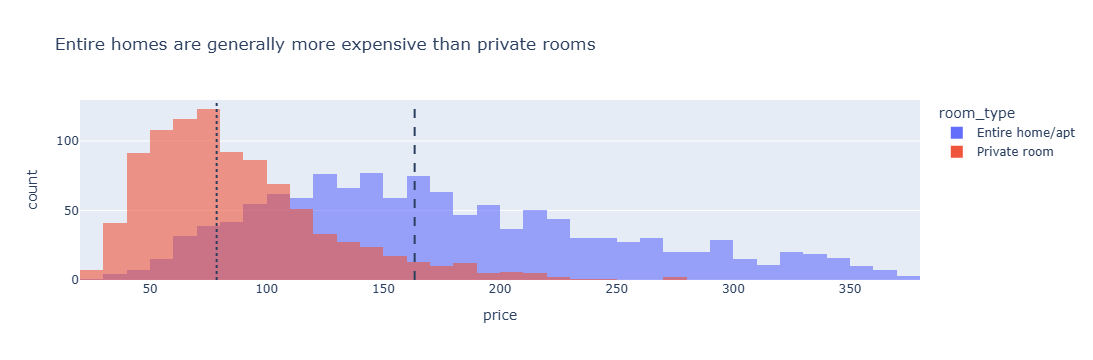

In [7]:
df_room = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

fig = px.histogram(
    df_room,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    title='Entire homes are generally more expensive than private rooms'
)

# Median lines
median_entire = df_room[df_room['room_type'] == 'Entire home/apt']['price'].median()
median_private = df_room[df_room['room_type'] == 'Private room']['price'].median()

fig.add_vline(x=median_entire, line_dash='dash')
fig.add_vline(x=median_private, line_dash='dot')

fig.show()


Insight : Entire home listings are generally priced higher than private rooms, shown by the right-shifted distribution.
The median price for entire homes is noticeably above that of private rooms.
Private room prices are more concentrated in the lower price range with less variation.
Some overlap exists, meaning budget entire homes can still compete with premium private rooms.

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

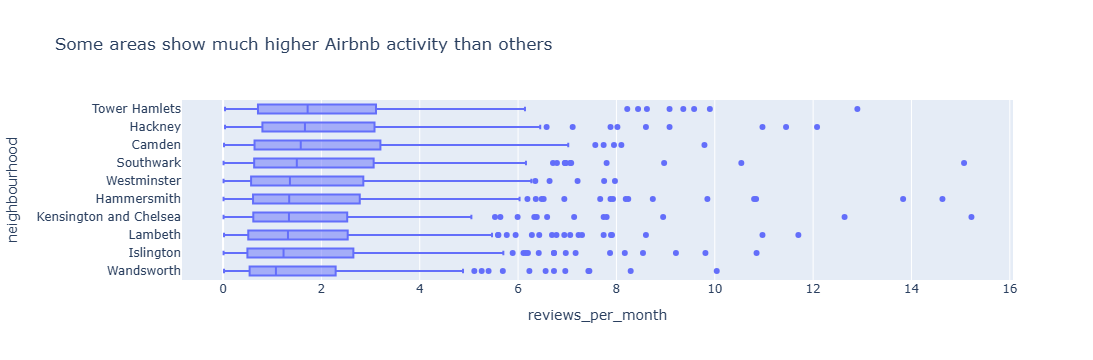

In [8]:
df_reviews = df_cap[df_cap['reviews_per_month'] > 0]

borough_order = (
    df_reviews.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .index
)

fig = px.box(
    df_reviews,
    x='reviews_per_month',
    y='neighbourhood',
    orientation='h',
    points='outliers',
    category_orders={'neighbourhood': borough_order},
    title='Some areas show much higher Airbnb activity than others'
)

fig.show()


Insight : The boroughs with the highest median reviews per month appear to have the most active Airbnb markets.
Higher review frequency suggests listings in these areas are booked more consistently.
Several boroughs show wide spreads and many outliers, indicating uneven performance across listings.
Listings with zero reviews were excluded, removing inactive or newly listed properties from the analysis.